In [15]:
# ==========================================
# 1. IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import gc

# Reprodutibilidade
tf.random.set_seed(42)
np.random.seed(42)


In [16]:
# ==========================================
# 2. CARREGAMENTO DOS DADOS (.npz)
# ==========================================
DATA_PATH = "/kaggle/input/datasets/lscolombo/opportunity-for-rp/opportunity_for_rp.npz"

print("Carregando dados do Opportunity...")
try:
    data = np.load(DATA_PATH, allow_pickle=True)

    # Os splits já vêm definidos do script gerador (LOSO)
    X_train = data['X_train']
    y_train = data['y_train']
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']

    # Recuperar os nomes originais das classes salvos pelo LabelEncoder, se precisar
    if 'classes' in data:
        classes_originais = data['classes']

    num_classes = len(np.unique(y_train))

    print(f"Shape X_train: {X_train.shape}")
    print(f"Shape X_val:   {X_val.shape}")
    print(f"Shape X_test:  {X_test.shape}")
    print(f"Número de classes ativas: {num_classes}")

except FileNotFoundError:
    print(f"ERRO: O arquivo {DATA_PATH} não foi encontrado.")
    print("Por favor, certifique-se de executar o notebook de pré-processamento primeiro ou de ter o arquivo disponível.")

Carregando dados do Opportunity...
Shape X_train: (12411, 75, 242)
Shape X_val:   (5852, 75, 242)
Shape X_test:  (5198, 75, 242)
Número de classes ativas: 18


In [17]:
# ==========================================
# 3. CÁLCULO E SUAVIZAÇÃO DOS PESOS DE CLASSE
# ==========================================
print("\nCalculando pesos para balanceamento das classes...")
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Keras exige os pesos no formato de dicionário
class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}

# TÁTICA ANTI-COLAPSO: Limitar o peso máximo (Clipping)
# Isso impede que classes muito raras tenham um peso que "quebre" a rede
TETO_MAXIMO = 10.0  # testar 5.0 ou 10.0

for k in class_weights_dict.keys():
    if class_weights_dict[k] > TETO_MAXIMO:
        class_weights_dict[k] = TETO_MAXIMO

print("Amostra dos pesos ajustados:")
for k in list(class_weights_dict.keys())[:5]:
    print(f"Classe {k} -> Peso: {class_weights_dict[k]:.4f}")


Calculando pesos para balanceamento das classes...
Amostra dos pesos ajustados:
Classe 0 -> Peso: 0.0770
Classe 1 -> Peso: 4.3639
Classe 2 -> Peso: 5.1074
Classe 3 -> Peso: 7.2579
Classe 4 -> Peso: 3.4823


In [18]:
# ==========================================
# 4A. GERAÇÃO VETORIZADA E PARALELA DOS URPs
# ==========================================
import numpy as np
import cv2
from tensorflow.keras.applications.resnet50 import preprocess_input
from joblib import Parallel, delayed
from scipy.spatial.distance import cdist
import os

# 1. DEFINIÇÃO DOS ÍNDICES (Sensor BACK acc)
# Baseado nos seus experimentos anteriores: X:36, Y:37, Z:38
idx_x = [36]   
idx_y = [37]  
idx_z = [38]  

# idx_others: Todas as outras 239 colunas para a CNN 1D
todas_colunas = list(range(X_train.shape[2]))
idx_others = [i for i in todas_colunas if i not in [36, 37, 38]]

# 2. FUNÇÃO DE PROCESSAMENTO (Isolada para os Workers)
def generate_single_urp(window, idx_x_vars, idx_y_vars, idx_z_vars, target_img_size=(112, 112)):
    # Vetorização com cdist: muito mais rápido que o loop original
    dist_r = cdist(window[:, idx_x_vars], window[:, idx_x_vars], metric='euclidean')
    dist_g = cdist(window[:, idx_y_vars], window[:, idx_y_vars], metric='euclidean')
    dist_b = cdist(window[:, idx_z_vars], window[:, idx_z_vars], metric='euclidean')
    
    img = np.stack([dist_r, dist_g, dist_b], axis=-1)
    
    # Normalização local por janela (evita data leakage)
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
        
    img = (1.0 - img) ** 3  # Realce de contraste cúbico
    img *= 255.0
    
    img_resized = cv2.resize(img, target_img_size, interpolation=cv2.INTER_LINEAR)
    return preprocess_input(img_resized)

# 3. FUNÇÃO ORQUESTRADORA (Paralelismo)
def precompute_urp_images_parallel(X_series, x_idx, y_idx, z_idx):
    print(f"Gerando {len(X_series)} imagens URP usando todos os núcleos da CPU...")
    results = Parallel(n_jobs=-1, batch_size='auto')(
        delayed(generate_single_urp)(X_series[i], x_idx, y_idx, z_idx) 
        for i in range(len(X_series))
    )
    return np.array(results, dtype=np.float32)

# 4. EXECUÇÃO E PERSISTÊNCIA
if not os.path.exists('X_train_urp.npy'):
    print("Iniciando processamento pesado (Treino)...")
    X_train_urp = precompute_urp_images_parallel(X_train, idx_x, idx_y, idx_z)
    np.save('X_train_urp.npy', X_train_urp)
    del X_train_urp # Libera RAM após salvar
    
    print("Iniciando processamento (Validação)...")
    X_val_urp = precompute_urp_images_parallel(X_val, idx_x, idx_y, idx_z)
    np.save('X_val_urp.npy', X_val_urp)
    del X_val_urp
    
    print("Iniciando processamento (Teste)...")
    X_test_urp = precompute_urp_images_parallel(X_test, idx_x, idx_y, idx_z)
    np.save('X_test_urp.npy', X_test_urp)
    del X_test_urp
    
    print("\n Todas as imagens URP foram geradas e salvas com sucesso!")
else:
    print(" Arquivos URP encontrados no disco. Pulando geração para economizar tempo.")

# ==========================================\n# 4B. MAPEAMENTO DE FEATURES E DATA GENERATOR\n# ==========================================
print("Carregando arrays do disco...")
X_train_img = np.load('X_train_urp.npy')
X_val_img   = np.load('X_val_urp.npy')
X_test_img  = np.load('X_test_urp.npy')

# Separe as features 1D
X_train_1d = X_train[:, :, idx_others]
X_val_1d   = X_val[:, :, idx_others]
X_test_1d  = X_test[:, :, idx_others]

def create_tf_dataset(X_img, X_1d, y, batch_size=32, is_training=False):
    dataset = tf.data.Dataset.from_tensor_slices(((X_img, X_1d), y))
    if is_training:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

batch_size = 32
train_gen = create_tf_dataset(X_train_img, X_train_1d, y_train, batch_size, is_training=True)
val_gen   = create_tf_dataset(X_val_img, X_val_1d, y_val, batch_size, is_training=False)
test_gen  = create_tf_dataset(X_test_img, X_test_1d, y_test, batch_size, is_training=False)

Iniciando processamento pesado (Treino)...
Gerando 12411 imagens URP usando todos os núcleos da CPU...


2026-05-02 02:08:28.215719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-02 02:08:28.215719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-02 02:08:28.215719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-02 02:08:28.215722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777687708.256525    5516 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already b

Iniciando processamento (Validação)...
Gerando 5852 imagens URP usando todos os núcleos da CPU...
Iniciando processamento (Teste)...
Gerando 5198 imagens URP usando todos os núcleos da CPU...

 Todas as imagens URP foram geradas e salvas com sucesso!
Carregando arrays do disco...


I0000 00:00:1777687752.261270    5326 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777687752.266421    5326 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [19]:
# ==========================================
# 5. CONSTRUÇÃO DO MODELO LATE FUSION
# ==========================================
def build_opportunity_late_fusion(num_classes, num_other_features=len(idx_others), window_size=75):
    # --- RAMO 1: Visão Computacional (ResNet50 para Imagens URP) ---
    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")

    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    # Congelar bases antigas (transfer learning), manter as últimas destravadas
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(128, activation='relu')(x_img)
    x_img = layers.Dropout(0.3)(x_img)

    # --- RAMO 2: CNN 1D para Séries Temporais Brutas ---
    input_1d = layers.Input(shape=(window_size, num_other_features), name="input_1d_series")

    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(64, activation='relu')(x_1d)

    # --- FUSÃO (Merge e Classificação Final) ---
    merged = layers.concatenate([x_img, x_1d])

    z = layers.Dense(128, activation='relu')(merged)
    z = layers.Dropout(0.4)(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

    model = models.Model(inputs=[input_img, input_1d], outputs=output)
    return model

model = build_opportunity_late_fusion(num_classes=num_classes)

In [20]:
# ==========================================
# 6. COMPILAÇÃO E TREINAMENTO AJUSTADO
# ==========================================
model.compile(
    # Reduzindo o LR de 0.0005 para 0.0001 (1e-4) para um aprendizado mais cauteloso
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Aumentar a paciência do Early Stopping já que o aprendizado será mais lento
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("\nIniciando Treinamento...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)


Iniciando Treinamento...
Epoch 1/40


I0000 00:00:1777687779.947784    5549 service.cc:152] XLA service 0x7b40d4003d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777687779.947835    5549 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777687779.947842    5549 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777687782.558695    5549 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/388 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.0243 - loss: 638.7479     

I0000 00:00:1777687791.951305    5549 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


388/388 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - accuracy: 0.0915 - loss: 157.8749 - val_accuracy: 0.0602 - val_loss: 4.6947 - learning_rate: 1.0000e-04
Epoch 2/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.1117 - loss: 2.4214 - val_accuracy: 0.0631 - val_loss: 3.8307 - learning_rate: 1.0000e-04
Epoch 3/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.1447 - loss: 1.8037 - val_accuracy: 0.0624 - val_loss: 4.2317 - learning_rate: 1.0000e-04
Epoch 4/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.1796 - loss: 1.5912 - val_accuracy: 0.0795 - val_loss: 4.4258 - learning_rate: 1.0000e-04
Epoch 5/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.2245 - loss: 1.3889 - val_accuracy: 0.1152 - val_loss: 4.2710 - learning_rate: 1.0000e-04
Epoch 6/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.2553 - loss: 1.0976 - val_accuracy: 0.1270 - val_loss: 4.0854 - learning_rate: 5.0000e-05
Epoch 7/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accur


[DEBUG 1] Iniciando model.evaluate()...
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5894 - loss: nan
[DEBUG 1] evaluate() concluído! Acurácia: 0.4134

[DEBUG 2] Iniciando model.predict()...
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
[DEBUG 2] predict() concluído!

[DEBUG 3] Extraindo rótulos verdadeiros (y_true)...
[DEBUG 3] Extração concluída. Shape: (5198,)

[DEBUG 4] Gerando relatórios...
              precision    recall  f1-score   support

           0       0.74      0.81      0.77      3815
           1       0.08      0.11      0.09        61
           2       0.07      0.13      0.09        46
           3       0.09      0.05      0.07        37
           4       0.00      0.00      0.00        82
           5       0.01      0.01      0.01        73
           6       0.10      0.05      0.07        38
           7       0.18      0.10      0.13       110
           8       0.00      0.00      0.00        57
           9       0.04      0.02      0.02        5

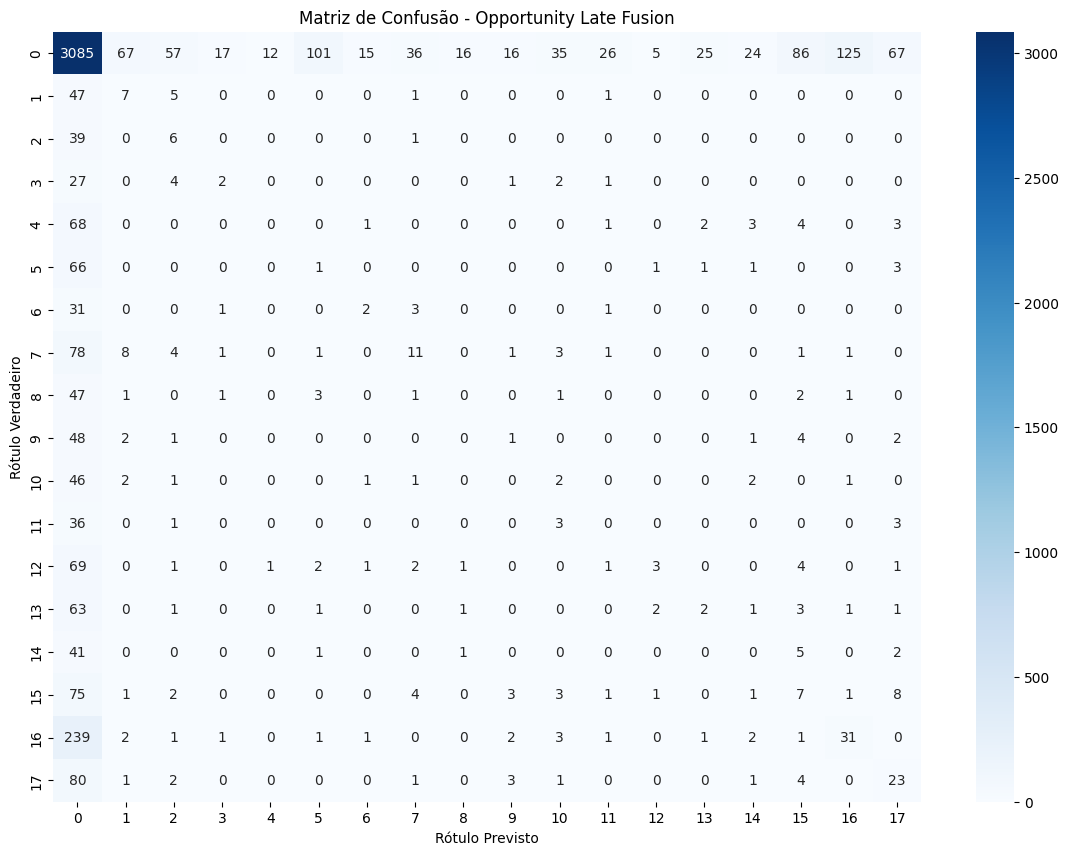

In [22]:
# ==========================================
# 7. AVALIAÇÃO DO MODELO (CORRIGIDA)
# ==========================================

print("\n[DEBUG 1] Iniciando model.evaluate()...")
test_loss, test_acc = model.evaluate(test_gen)
print(f"[DEBUG 1] evaluate() concluído! Acurácia: {test_acc:.4f}")

print("\n[DEBUG 2] Iniciando model.predict()...")
# Predict direto no dataset
batch_probs = model.predict(test_gen)
y_pred = np.argmax(batch_probs, axis=1)
print("[DEBUG 2] predict() concluído!")

print("\n[DEBUG 3] Extraindo rótulos verdadeiros (y_true)...")
# Forma correta de extrair labels de um tf.data.Dataset
y_true = np.concatenate([y for x, y in test_gen], axis=0)
print(f"[DEBUG 3] Extração concluída. Shape: {y_true.shape}")

# Ajuste para garantir que y_true e y_pred tenham o mesmo tamanho
# (Às vezes o dataset de teste tem um resto de batch que o predict ignora se não configurado)
y_pred = y_pred[:len(y_true)]

print("\n[DEBUG 4] Gerando relatórios...")
print(classification_report(y_true, y_pred))

# Plot da Matriz de Confusão
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Opportunity Late Fusion')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()


Gerando amostras de Recurrence Plots (URP) para cada classe...


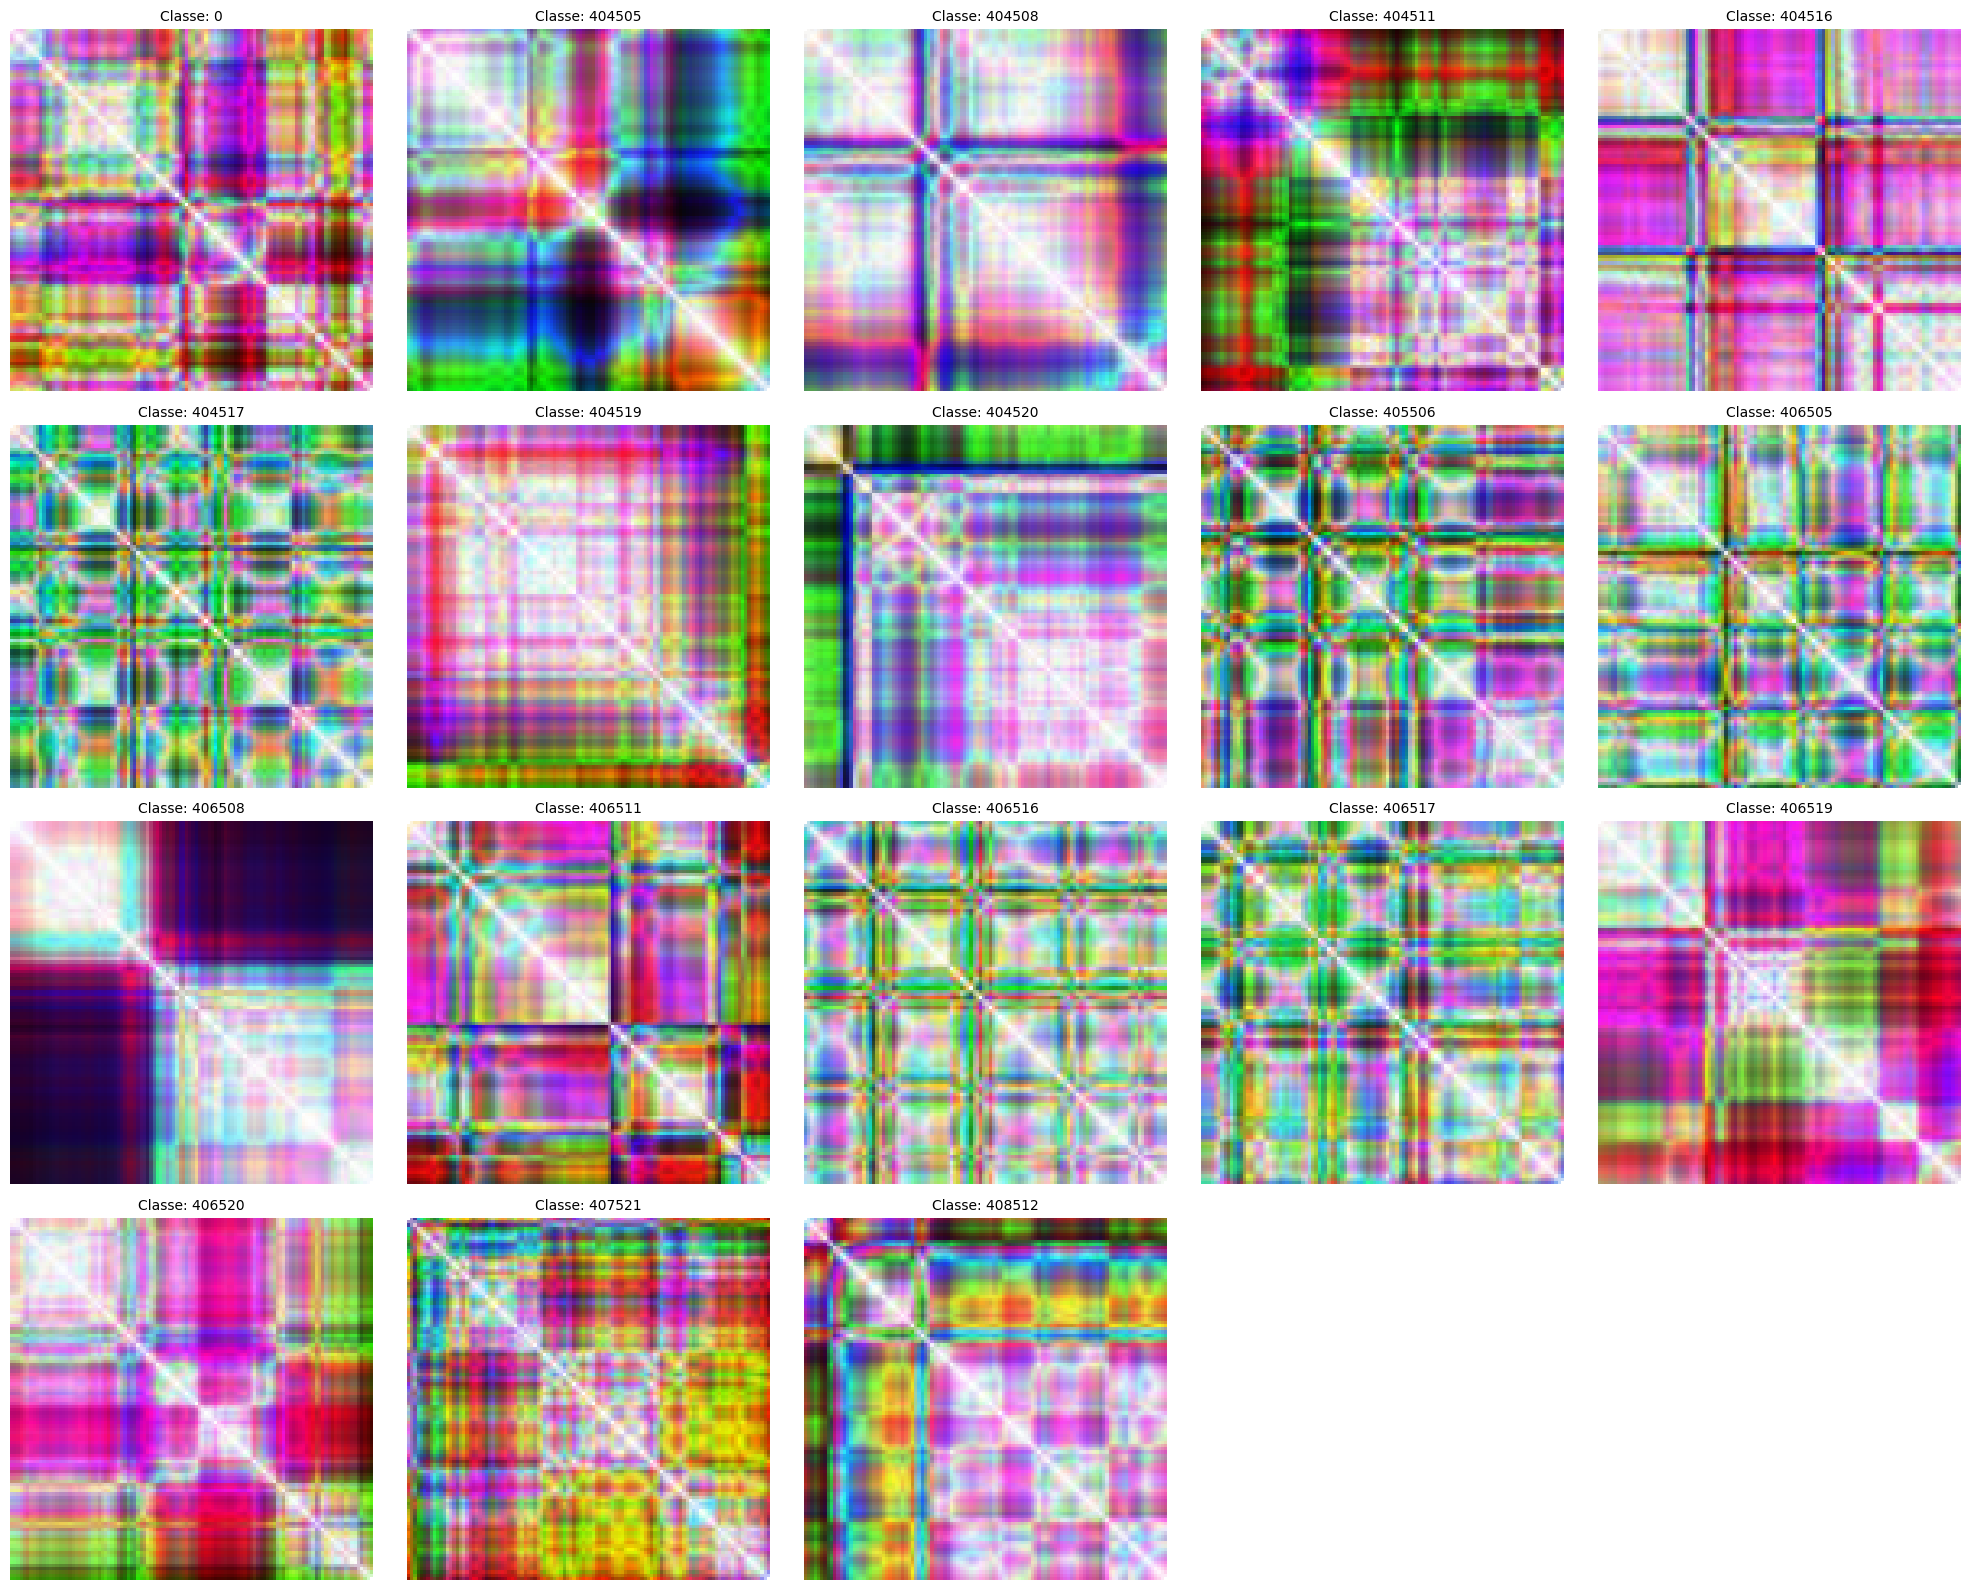

In [23]:
# ==========================================
# 8. VISUALIZAÇÃO DOS RECURRENCE PLOTS (URP) POR CLASSE
# ==========================================
print("\nGerando amostras de Recurrence Plots (URP) para cada classe...")
unique_classes = np.unique(y_train)
num_unique_classes = len(unique_classes)

cols = 5
rows = int(np.ceil(num_unique_classes / cols))
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, cls in enumerate(unique_classes):
    # Encontrar a primeira amostra pertencente a esta classe
    sample_idx = np.where(y_train == cls)[0][0]
    window = X_train[sample_idx]

    dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
    dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
    dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

    img = np.stack([dist_r, dist_g, dist_b], axis=-1)

    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)

    img = (1.0 - img) ** 3

    # Para visualização, mantemos a escala [0, 1] original sem preprocess_input,
    # pois o preprocess_input distorce as cores para exibição no matplotlib
    img_resized = cv2.resize(img, (112, 112), interpolation=cv2.INTER_LINEAR)

    # Tenta usar as classes originais se foram salvas, senão usa o próprio ID numérico
    try:
        original_label = classes_originais[cls]
    except:
        original_label = cls

    ax = axes[i]
    ax.imshow(img_resized)
    ax.set_title(f'Classe: {original_label}', fontsize=10)
    ax.axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Experimento 2: Otimização de Hiperparâmetros com Optuna
Nesta seção, vamos utilizar o **Optuna** para encontrar a melhor combinação de hiperparâmetros para o nosso modelo Late Fusion. Vamos otimizar:
- A taxa de aprendizado (Learning Rate)
- A taxa de Dropout (para evitar overfitting)
- O número de neurônios na camada Densa (Visão e Fusão)

In [24]:
!pip install optuna

## Otimização: Pré-computação das Imagens URP em RAM
Para evitar que a CPU seja o gargalo do treinamento recriando os *Recurrence Plots* (URP) a cada época, geramos as matrizes de distância apenas uma vez antes do treinamento. Elas são mantidas na RAM e entregues quase instantaneamente à GPU, economizando muitas horas de processamento, especialmente na etapa do Optuna.

In [25]:
import numpy as np
import cv2
from scipy.spatial.distance import pdist, squareform
from tensorflow.keras import applications
import tensorflow as tf

print("Iniciando pré-computação das matrizes URP na RAM...")
print("Isso levará alguns instantes iniciais, mas economizará HORAS de CPU durante o Optuna!\n")

def precompute_urps(X_data):
    N = len(X_data)
    # Alocando os arrays que ficarão em memória
    X_img = np.zeros((N, 112, 112, 3), dtype=np.float32)
    X_1d = X_data[:, :, idx_others]

    for i in range(N):
        window = X_data[i]
        # Matrizes de Distância Euclidiana baseada na Janela temporal
        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

        # Empilhar canais RGB e normalizar
        img = np.stack([dist_r, dist_g, dist_b], axis=-1)
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)

        # Inversão e Contraste Cúbico
        img = (1.0 - img) ** 3
        img = img * 255.0 # Escala para pré-processamento ResNet

        # Resize e Preprocess_input
        img_resized = cv2.resize(img, (112, 112), interpolation=cv2.INTER_LINEAR)
        X_img[i] = applications.resnet50.preprocess_input(img_resized)

        if (i+1) % 5000 == 0:
            print(f"  -> Processado {i+1}/{N} amostras...")

    return X_img, X_1d

print("1. Processando conjunto de Treino...")
X_train_img, X_train_1d = precompute_urps(X_train)
print("\n2. Processando conjunto de Validação...")
X_val_img, X_val_1d = precompute_urps(X_val)
print("\n3. Processando conjunto de Teste...")
X_test_img, X_test_1d = precompute_urps(X_test)

# --- GERADOR ULTRA-RÁPIDO ---
import numpy as np
import tensorflow as tf

print("Preparando DataGenerators rápidos em RAM para o Optuna...")

# --- GERADOR ULTRA-RÁPIDO ---
# (Seu código original modificado para apenas receber os dados)[cite: 1]
class FastDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X_img, X_1d, y, batch_size=32, shuffle=True):
        self.X_img = X_img
        self.X_1d = X_1d
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.y))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.floor(len(self.y) / self.batch_size))

    def __getitem__(self, index):
        start_idx = index * self.batch_size
        end_idx = (index + 1) * self.batch_size
        batch_indexes = self.indexes[start_idx:end_idx]

        return (self.X_img[batch_indexes], self.X_1d[batch_indexes]), self.y[batch_indexes]

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Aqui nós apenas REUTILIZAMOS os dados que carregamos na Célula 4B
batch_size = 32
optuna_train_gen = FastDataGenerator(X_train_img, X_train_1d, y_train, batch_size=batch_size)
optuna_val_gen = FastDataGenerator(X_val_img, X_val_1d, y_val, batch_size=batch_size, shuffle=False)
optuna_test_gen = FastDataGenerator(X_test_img, X_test_1d, y_test, batch_size=batch_size, shuffle=False)

print("Geradores em memória prontos para o Optuna!")

Iniciando pré-computação das matrizes URP na RAM...
Isso levará alguns instantes iniciais, mas economizará HORAS de CPU durante o Optuna!

1. Processando conjunto de Treino...
  -> Processado 5000/12411 amostras...
  -> Processado 10000/12411 amostras...

2. Processando conjunto de Validação...
  -> Processado 5000/5852 amostras...

3. Processando conjunto de Teste...
  -> Processado 5000/5198 amostras...
Preparando DataGenerators rápidos em RAM para o Optuna...
Geradores em memória prontos para o Optuna!


In [26]:
import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks

def build_optuna_model(trial, num_classes):
    # Sugestões de Hiperparâmetros pelo Optuna
    dense_img_units = trial.suggest_categorical('dense_img_units', [64, 128, 256])
    dropout_img = trial.suggest_float('dropout_img', 0.2, 0.5)

    dense_1d_units = trial.suggest_categorical('dense_1d_units', [32, 64, 128])

    dense_fusion_units = trial.suggest_categorical('dense_fusion_units', [64, 128, 256])
    dropout_fusion = trial.suggest_float('dropout_fusion', 0.2, 0.5)

    # --- RAMO 1: Visão ---
    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(dense_img_units, activation='relu')(x_img)
    x_img = layers.Dropout(dropout_img)(x_img)

    # --- RAMO 2: CNN 1D ---
    input_1d = layers.Input(shape=(75, len(idx_others)), name="input_1d_series")
    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(dense_1d_units, activation='relu')(x_1d)

    # --- FUSÃO ---
    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(dense_fusion_units, activation='relu')(merged)
    z = layers.Dropout(dropout_fusion)(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

    model = models.Model(inputs=[input_img, input_1d], outputs=output)

    # Sugestão de Learning Rate
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def objective(trial):
    # Limpar a sessão do Keras para evitar estouro de memória entre os trials
    tf.keras.backend.clear_session()

    model = build_optuna_model(trial, num_classes)

    # Early stopping mais agressivo para os trials do Optuna
    early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

    # Vamos usar menos épocas na busca para não demorar uma eternidade
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        class_weight=class_weights_dict,
        callbacks=[early_stopping],
        verbose=0 # Reduzir os logs no console durante o Optuna
    )

    # O objetivo é maximizar a acurácia de validação
    val_acc = max(history.history['val_accuracy'])
    return val_acc

print("Iniciando Optuna Study...")
study = optuna.create_study(direction='maximize')
# Vamos realizar 10 tentativas iniciais para otimizar os hiperparâmetros (aumente n_trials se desejar)
study.optimize(objective, n_trials=10)

print("\n--- RESULTADOS DO OPTUNA ---")
print(f"Melhor Trial: {study.best_trial.number}")
print(f"Melhor Acurácia de Validação: {study.best_value:.4f}")
print("Melhores Hiperparâmetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")


[I 2026-05-02 02:30:58,660] A new study created in memory with name: no-name-5ac66b28-d22a-4c38-9467-ae3f86d43df7


Iniciando Optuna Study...


[I 2026-05-02 02:34:41,287] Trial 0 finished with value: 0.1421736180782318 and parameters: {'dense_img_units': 64, 'dropout_img': 0.46931465576639547, 'dense_1d_units': 32, 'dense_fusion_units': 256, 'dropout_fusion': 0.3203400184726878, 'learning_rate': 0.0001238189408900398}. Best is trial 0 with value: 0.1421736180782318.
[I 2026-05-02 02:38:25,286] Trial 1 finished with value: 0.10748462378978729 and parameters: {'dense_img_units': 64, 'dropout_img': 0.3368656775583531, 'dense_1d_units': 128, 'dense_fusion_units': 256, 'dropout_fusion': 0.20103286969879067, 'learning_rate': 0.0005785458702843556}. Best is trial 0 with value: 0.1421736180782318.
[I 2026-05-02 02:40:15,995] Trial 2 finished with value: 0.10987696796655655 and parameters: {'dense_img_units': 64, 'dropout_img': 0.4218684320461211, 'dense_1d_units': 64, 'dense_fusion_units': 256, 'dropout_fusion': 0.25380671849090486, 'learning_rate': 2.1217952196492712e-05}. Best is trial 0 with value: 0.1421736180782318.
[I 2026-05-0


--- RESULTADOS DO OPTUNA ---
Melhor Trial: 7
Melhor Acurácia de Validação: 0.1458
Melhores Hiperparâmetros:
  dense_img_units: 256
  dropout_img: 0.44864766498736175
  dense_1d_units: 64
  dense_fusion_units: 256
  dropout_fusion: 0.39593138562265595
  learning_rate: 4.402262463063729e-05


## Avaliação Padronizada dos Experimentos
Nesta seção, definimos as funções para extrair as métricas solicitadas de forma padronizada para cada modelo treinado:
1. **Curvas de Aprendizado** (Loss e Accuracy)
2. **Acurácia e F1-Score Médios (com desvio)** calculados através de Bootstrap
3. **Relatório de Classificação**
4. **Matriz de Confusão**
5. **Recurrence Plots (URP)** gerados para cada classe.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
import cv2
from scipy.spatial.distance import pdist, squareform

def plot_learning_curve(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Acurácia
    ax1.plot(history.history.get('accuracy', []), label='Treino')
    ax1.plot(history.history.get('val_accuracy', []), label='Validação')
    ax1.set_title(f'{title} - Acurácia')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Acurácia')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Loss
    ax2.plot(history.history.get('loss', []), label='Treino')
    ax2.plot(history.history.get('val_loss', []), label='Validação')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

def calc_bootstrap_metrics(y_true, y_pred, n_iterations=1000):
    acc_scores = []
    f1_scores = []
    n_size = len(y_true)

    for i in range(n_iterations):
        # Reamostragem com reposição
        idx = resample(np.arange(n_size), n_samples=n_size)
        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]

        acc_scores.append(accuracy_score(y_true_b, y_pred_b))
        f1_scores.append(f1_score(y_true_b, y_pred_b, average='macro'))

    mean_acc = np.mean(acc_scores)
    std_acc = np.std(acc_scores)
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)

    print(f"Bootstrap Acurácia: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Bootstrap F1-Score (Macro): {mean_f1:.4f} ± {std_f1:.4f}")
    return mean_acc, std_acc, mean_f1, std_f1

def plot_recurrence_by_class(X_data, y_data):
    unique_classes = np.unique(y_data)
    cols = 5
    rows = int(np.ceil(len(unique_classes) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten()

    for i, cls in enumerate(unique_classes):
        sample_idx = np.where(y_data == cls)[0][0]
        window = X_data[sample_idx]

        dist_r = squareform(pdist(window[:, idx_x], metric='euclidean'))
        dist_g = squareform(pdist(window[:, idx_y], metric='euclidean'))
        dist_b = squareform(pdist(window[:, idx_z], metric='euclidean'))

        img = np.stack([dist_r, dist_g, dist_b], axis=-1)
        img_min, img_max = img.min(), img.max()
        if img_max > img_min:
            img = (img - img_min) / (img_max - img_min)
        img = (1.0 - img) ** 3

        img_resized = cv2.resize(img, (112, 112), interpolation=cv2.INTER_LINEAR)

        try:
            original_label = classes_originais[cls]
        except:
            original_label = cls

        ax = axes[i]
        ax.imshow(img_resized)
        ax.set_title(f'Classe: {original_label}', fontsize=10)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

def evaluate_experiment(exp_model, exp_history, test_generator, X_train_data, y_train_data, title=""):
    print(f"\n{'='*50}")
    print(f" RESULTADOS: {title}")
    print(f"{'='*50}\n")

    print("1. Curva de Aprendizado")
    plot_learning_curve(exp_history, title)

    print("\n2. Obtendo predições do conjunto de teste...")
    y_pred_probs = exp_model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = []
    for _, labels in test_generator:
        y_true.extend(labels)
    y_true = np.array(y_true)

    print("\n3. Métricas via Bootstrap (1000 iterações)")
    calc_bootstrap_metrics(y_true, y_pred, n_iterations=1000)

    print("\n4. Relatório de Classificação")
    print(classification_report(y_true, y_pred))

    print("\n5. Matriz de Confusão")
    plt.figure(figsize=(14, 10))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {title}')
    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Previsto')
    plt.show()

    print("\n6. Recurrence Plots (Amostra por Classe)")
    plot_recurrence_by_class(X_train_data, y_train_data)

### Executando Avaliação para o Experimento 1 (Baseline)


 RESULTADOS: Experimento 1: Baseline (Sem Optuna)

1. Curva de Aprendizado


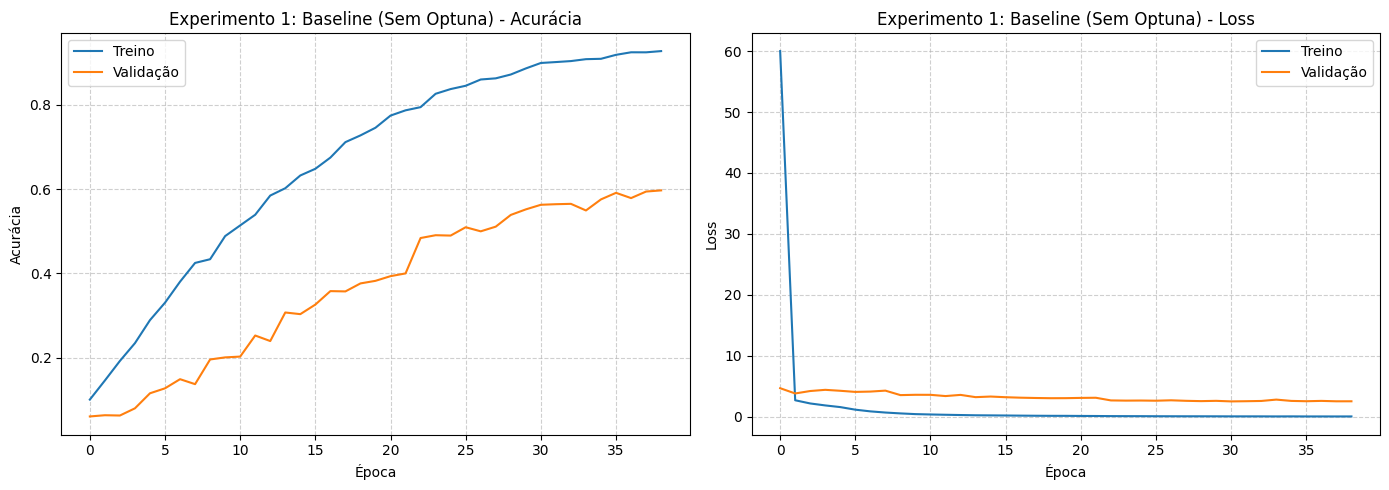


2. Obtendo predições do conjunto de teste...
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step

3. Métricas via Bootstrap (1000 iterações)
Bootstrap Acurácia: 0.6123 ± 0.0067
Bootstrap F1-Score (Macro): 0.0992 ± 0.0064

4. Relatório de Classificação
              precision    recall  f1-score   support

           0       0.74      0.81      0.77      3815
           1       0.08      0.11      0.09        61
           2       0.07      0.13      0.09        46
           3       0.09      0.05      0.07        37
           4       0.00      0.00      0.00        82
           5       0.01      0.01      0.01        73
           6       0.10      0.05      0.07        38
           7       0.18      0.10      0.13       110
           8       0.00      0.00      0.00        57
           9       0.04      0.02      0.02        59
          10       0.04      0.04      0.04        56
          11       0.00      0.00      0.00        43
          12       0.25      0.03      0.06        86


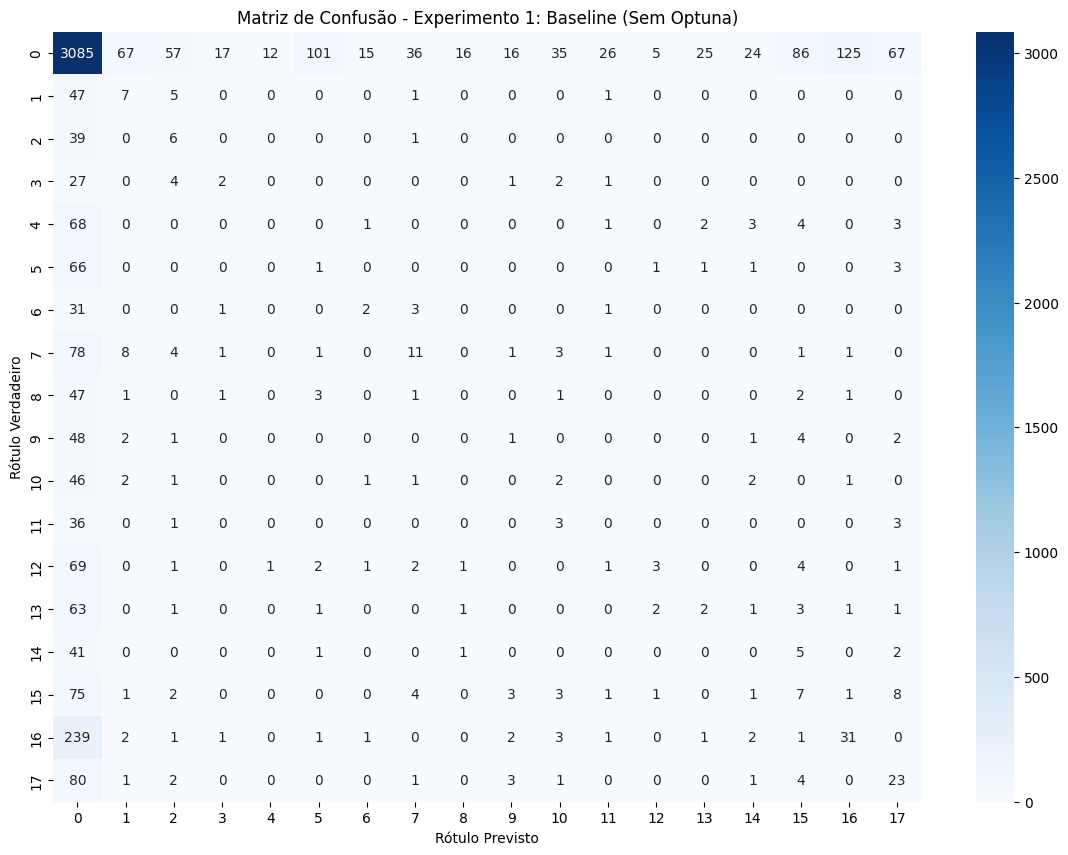


6. Recurrence Plots (Amostra por Classe)


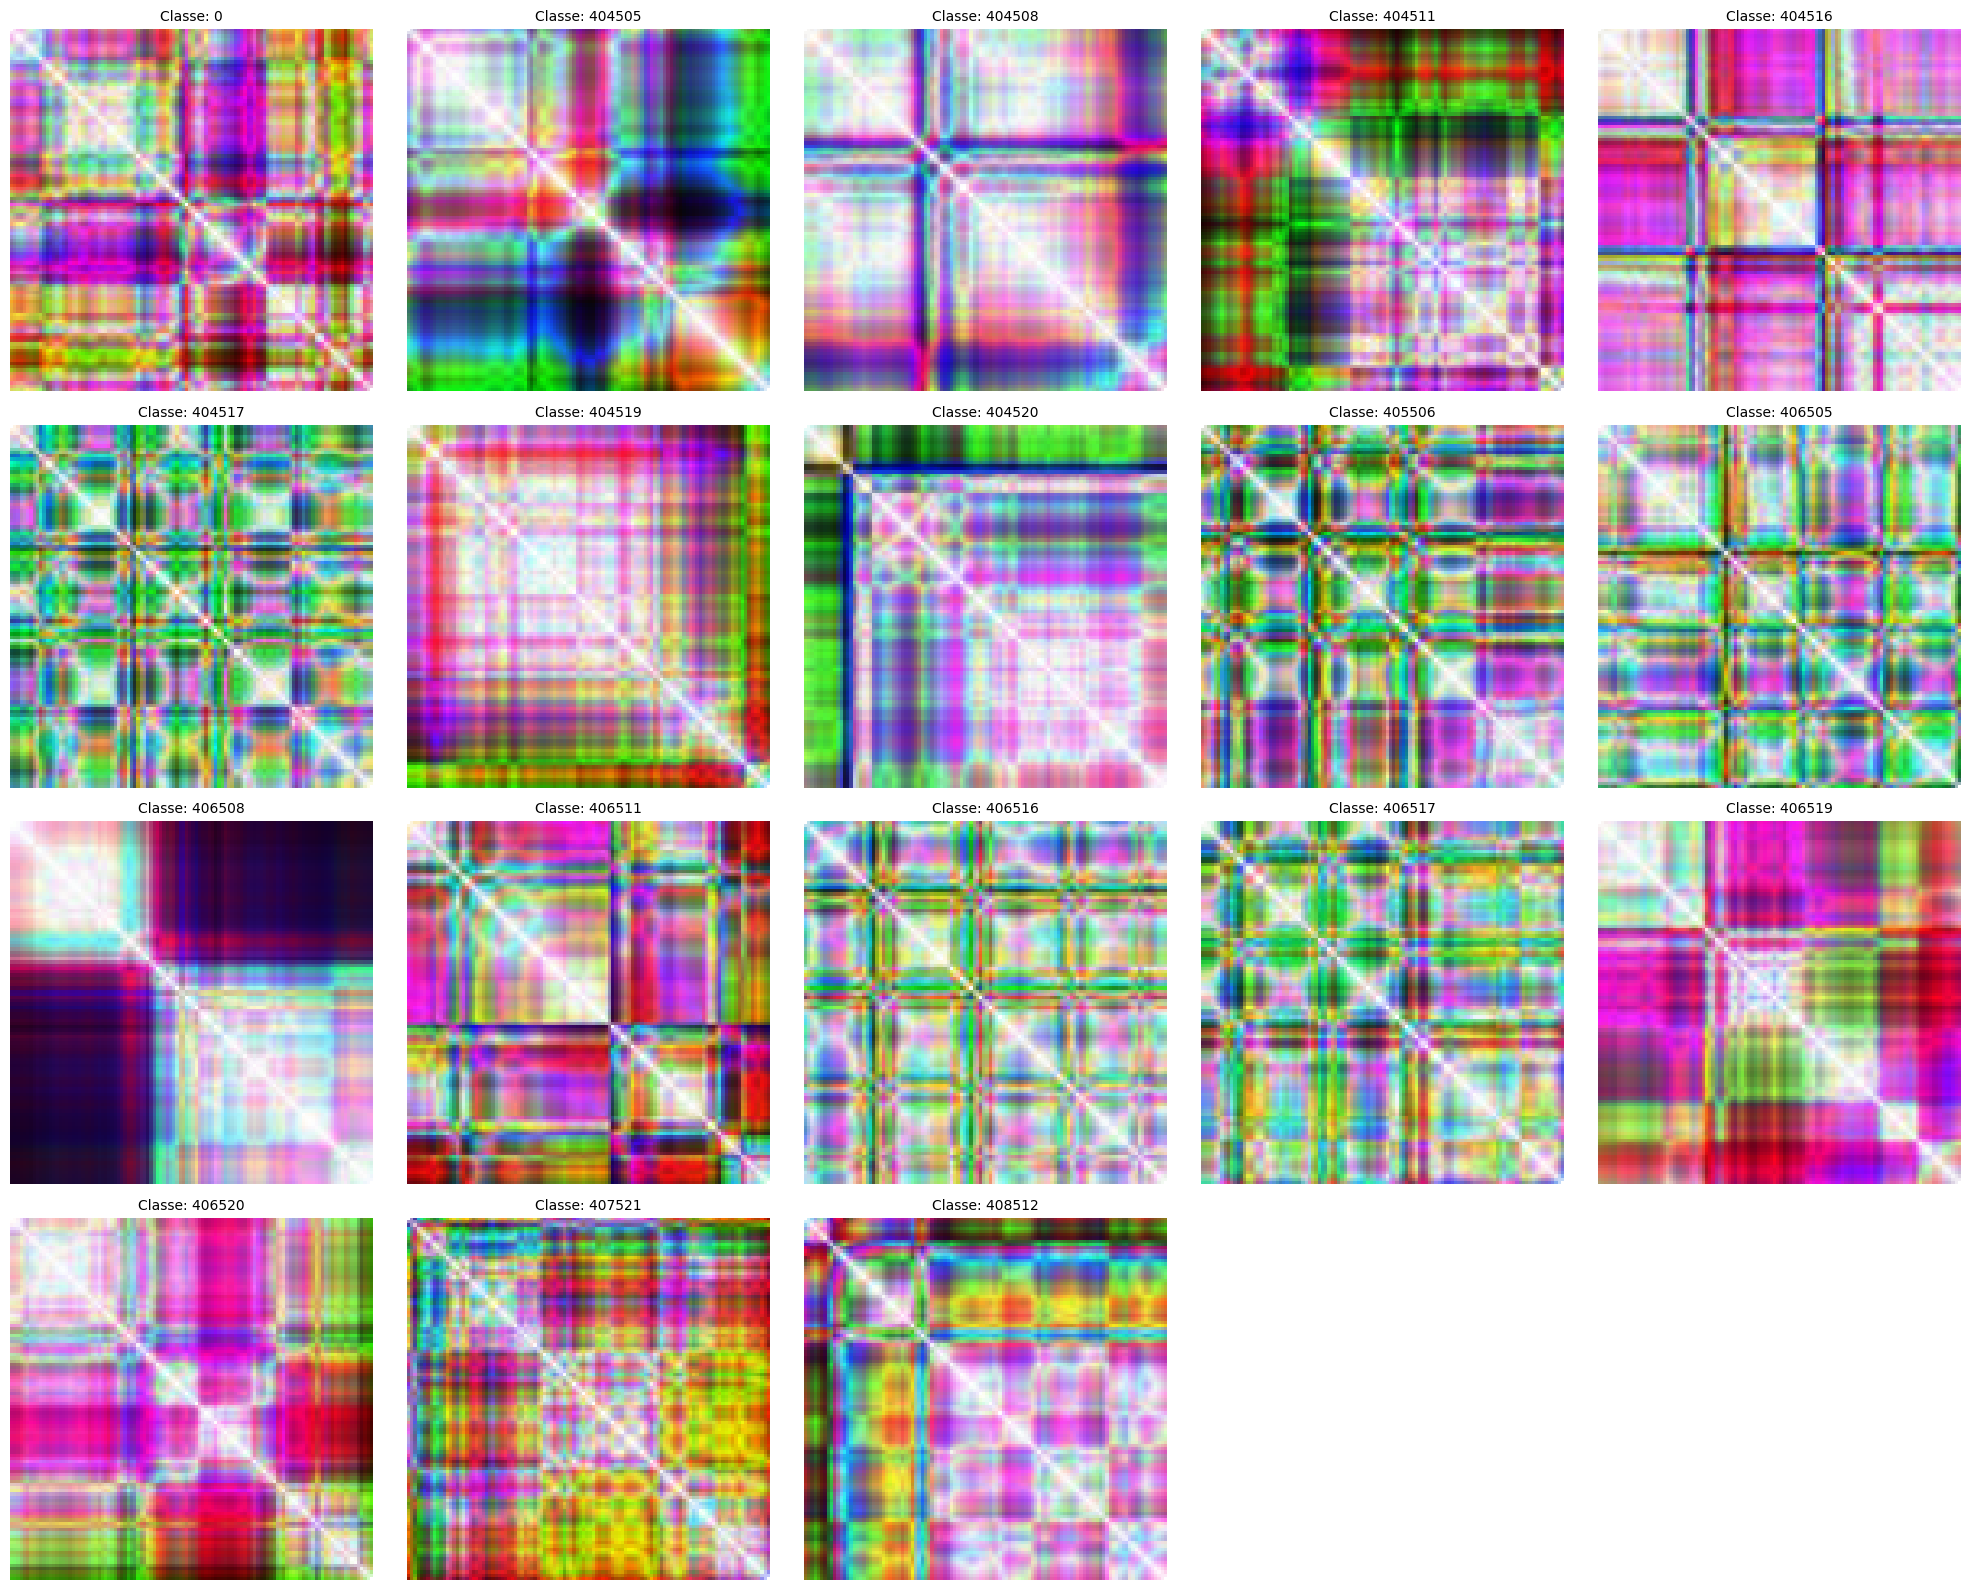

In [29]:
# O modelo e histórico base já estão na memória do notebook (célula anterior)
try:
    evaluate_experiment(model, history, test_gen, X_train, y_train, title="Experimento 1: Baseline (Sem Optuna)")
except NameError:
    print("Os dados do Experimento 1 não foram encontrados. Certifique-se de executar a célula de Treinamento e Compilação ajustada.")

### Treinamento Final e Avaliação do Experimento 2 (Optuna Best Model)


--- CONSTRUINDO O MELHOR MODELO (EXPERIMENTO 2) ---
Parâmetros utilizados: {'dense_img_units': 256, 'dropout_img': 0.44864766498736175, 'dense_1d_units': 64, 'dense_fusion_units': 256, 'dropout_fusion': 0.39593138562265595, 'learning_rate': 4.402262463063729e-05}

Treinando o modelo otimizado pelo Optuna (até 40 épocas)...
Epoch 1/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 52s 86ms/step - accuracy: 0.1017 - loss: 184.3758 - val_accuracy: 0.1381 - val_loss: 10.7640 - learning_rate: 4.4023e-05
Epoch 2/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1230 - loss: 5.0915 - val_accuracy: 0.0509 - val_loss: 4.7703 - learning_rate: 4.4023e-05
Epoch 3/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.1033 - loss: 2.5509 - val_accuracy: 0.0666 - val_loss: 3.9413 - learning_rate: 4.4023e-05
Epoch 4/40
388/388 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.1222 - loss: 2.0083 - val_accuracy: 0.0672 - val_loss: 3.7595 - learning_rate: 4.4023e-05
Epoch 5/40
388/388 ━━━━━━━━━━━━━━━━━━━━

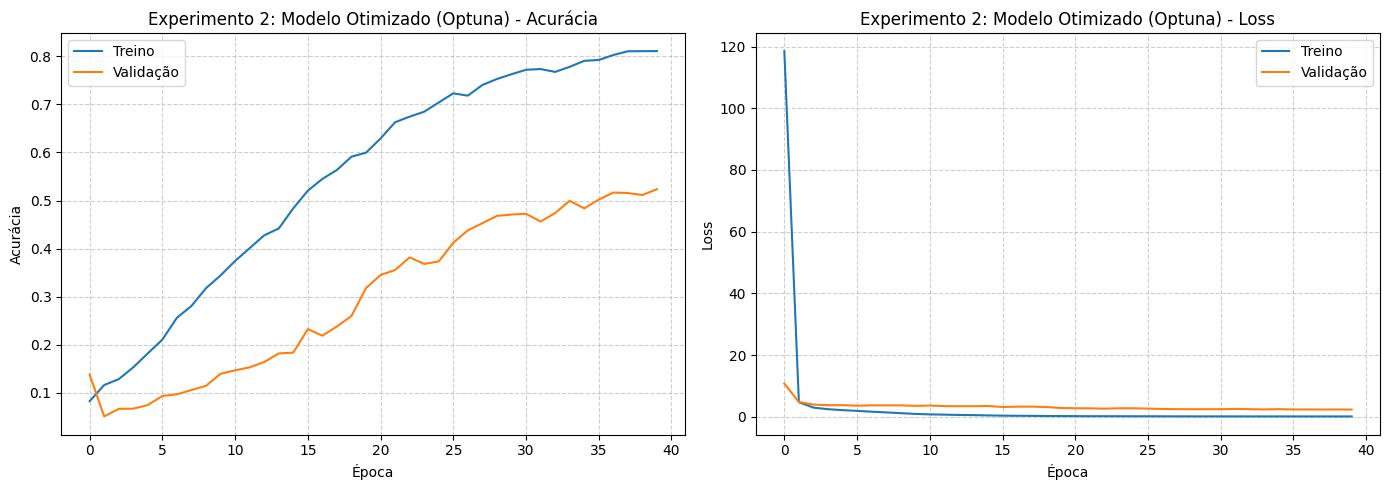


2. Obtendo predições do conjunto de teste...
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step

3. Métricas via Bootstrap (1000 iterações)
Bootstrap Acurácia: 0.5879 ± 0.0071
Bootstrap F1-Score (Macro): 0.1080 ± 0.0068

4. Relatório de Classificação
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      3815
           1       0.10      0.13      0.12        61
           2       0.07      0.15      0.09        46
           3       0.05      0.03      0.04        37
           4       0.07      0.01      0.02        82
           5       0.03      0.03      0.03        73
           6       0.11      0.05      0.07        38
           7       0.17      0.16      0.17       110
           8       0.00      0.00      0.00        57
           9       0.08      0.10      0.09        59
          10       0.04      0.07      0.06        56
          11       0.00      0.00      0.00        43
          12       0.01      0.01      0.01        86

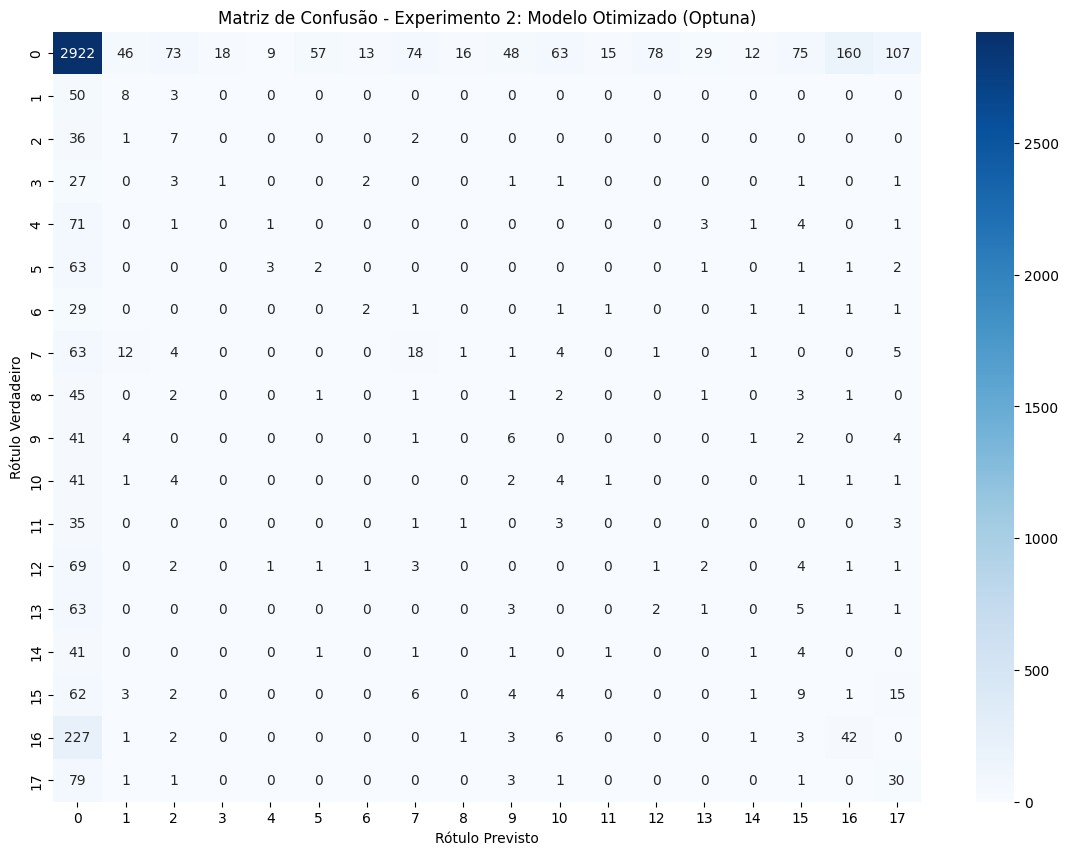


6. Recurrence Plots (Amostra por Classe)


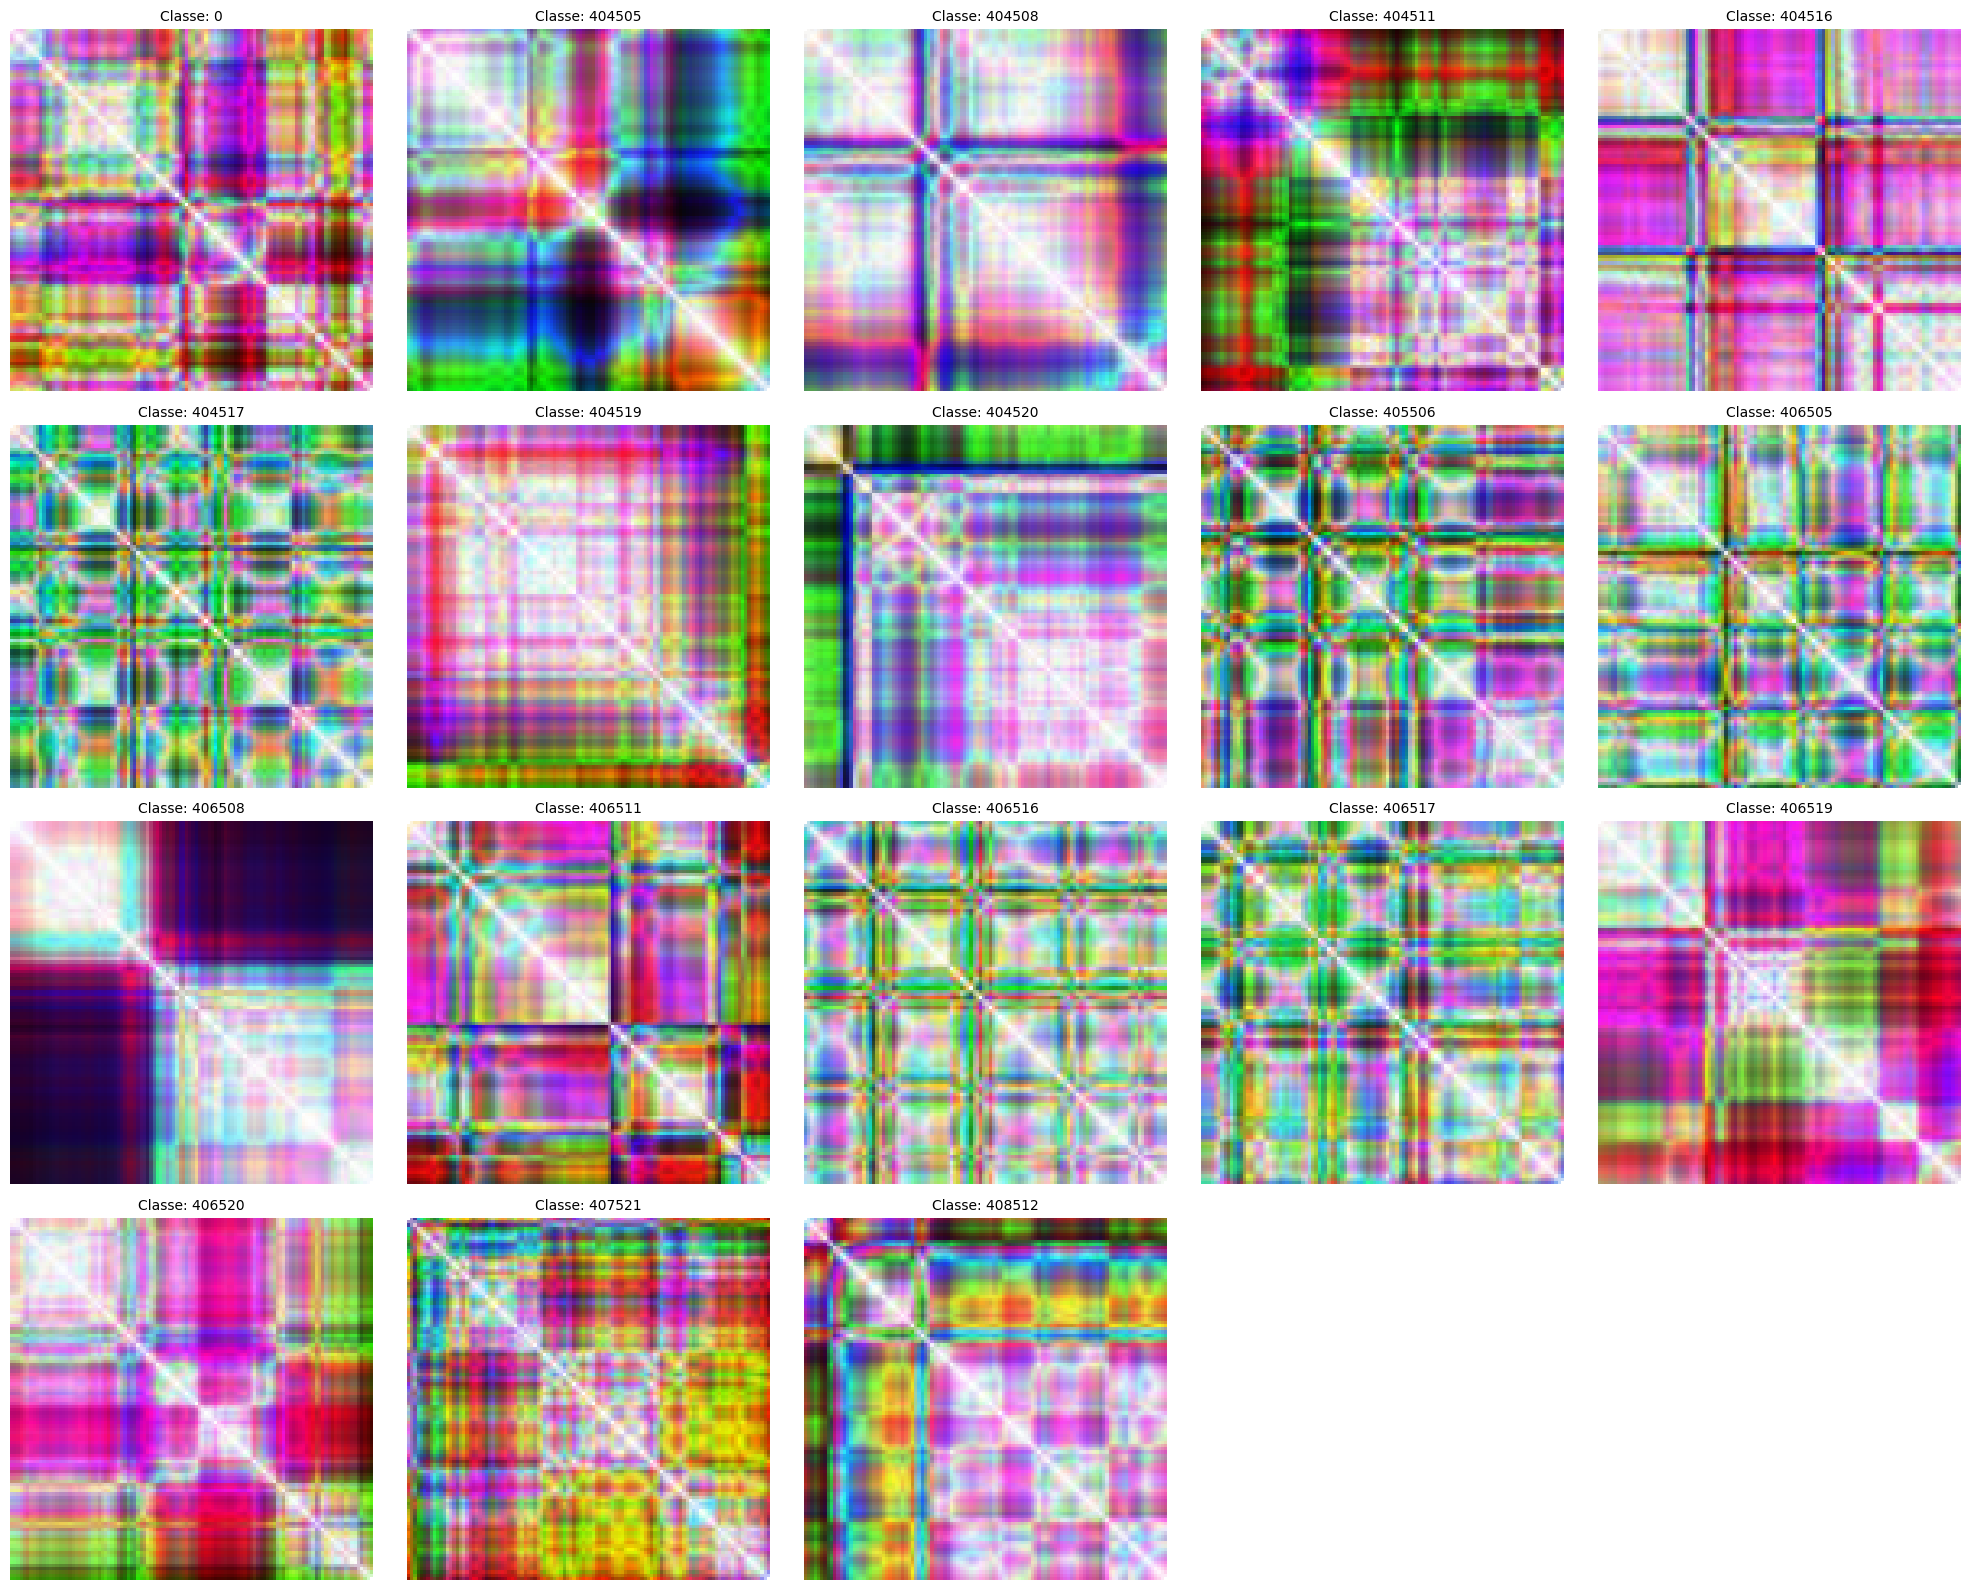

In [31]:
print("\n--- CONSTRUINDO O MELHOR MODELO (EXPERIMENTO 2) ---")

try:
    best_params = study.best_params
    print("Parâmetros utilizados:", best_params)

    # Reconstruir o modelo com os melhores parâmetros
    tf.keras.backend.clear_session()

    input_img = layers.Input(shape=(112, 112, 3), name="input_urp_img")
    base_resnet = applications.ResNet50(weights='imagenet', include_top=False, input_tensor=input_img)
    for layer in base_resnet.layers[:-15]:
        layer.trainable = False

    x_img = base_resnet.output
    x_img = layers.GlobalAveragePooling2D()(x_img)
    x_img = layers.Dense(best_params['dense_img_units'], activation='relu')(x_img)
    x_img = layers.Dropout(best_params['dropout_img'])(x_img)

    input_1d = layers.Input(shape=(X_train.shape[1], len(idx_others)), name="input_1d_series")
    x_1d = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x_1d)
    x_1d = layers.MaxPooling1D(pool_size=2)(x_1d)
    x_1d = layers.Flatten()(x_1d)
    x_1d = layers.Dense(best_params['dense_1d_units'], activation='relu')(x_1d)

    merged = layers.concatenate([x_img, x_1d])
    z = layers.Dense(best_params['dense_fusion_units'], activation='relu')(merged)
    z = layers.Dropout(best_params['dropout_fusion'])(z)
    output = layers.Dense(num_classes, activation='softmax', name="output_class")(z)

    best_model = models.Model(inputs=[input_img, input_1d], outputs=output)

    best_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping_best = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    reduce_lr_best = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    print("\nTreinando o modelo otimizado pelo Optuna (até 40 épocas)...")
    best_history = best_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=40,
        class_weight=class_weights_dict,
        callbacks=[early_stopping_best, reduce_lr_best],
        verbose=1
    )

    # Avaliação do Experimento 2
    evaluate_experiment(best_model, best_history, test_gen, X_train, y_train, title="Experimento 2: Modelo Otimizado (Optuna)")

except NameError:
    print("O estudo do Optuna não foi encontrado. Por favor, rode a célula do Optuna primeiro.")